In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization
from keras import Sequential
from keras.regularizers import l1_l2

In [2]:
# generators

train_df = tf.keras.utils.image_dataset_from_directory(
    directory='../DataSets/catsvsdogs/train',
    labels='inferred',
    label_mode= 'int',
    batch_size = 32,
    image_size=(256,256)
)

test_df = tf.keras.utils.image_dataset_from_directory(
    directory='../DataSets/catsvsdogs/test',
    labels='inferred',
    label_mode= 'int',
    batch_size = 32,
    image_size=(256,256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [3]:
def process(image, label):
    image = tf.cast(image/255. , tf.float32)
    return image, label

train_df = train_df.map(process)
test_df = test_df.map(process)

In [4]:
model = Sequential()

In [5]:
model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(MaxPool2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

f:\Learning\DL\Learning\Deep-Learning\ANN\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [11]:
history = model.fit(train_df, epochs=10, validation_data=test_df)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 197s 315ms/step - accuracy: 0.6570 - loss: 0.6200 - val_accuracy: 0.7022 - val_loss: 0.5763
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 190s 305ms/step - accuracy: 0.7552 - loss: 0.4981 - val_accuracy: 0.7572 - val_loss: 0.5192
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 184s 294ms/step - accuracy: 0.8469 - loss: 0.3466 - val_accuracy: 0.7688 - val_loss: 0.6383
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 190s 304ms/step - accuracy: 0.9288 - loss: 0.1797 - val_accuracy: 0.7438 - val_loss: 1.0318
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 199s 318ms/step - accuracy: 0.9655 - loss: 0.0949 - val_accuracy: 0.7460 - val_loss: 1.1969
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 182s 290ms/step - accuracy: 0.9776 - loss: 0.0644 - val_accuracy: 0.7542 - val_loss: 1.2475
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 186s 297ms/step - accuracy: 0.9869 - loss: 0.0428 - val_accuracy: 0.7586 - val_loss: 1.3765
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 186s 297ms/step - accuracy: 0.9872 -

In [12]:
import pickle

In [15]:
pickle.dump(model, open('cats_dogs.pkl', '+wb'))

In [16]:
cats_dogs = pickle.load(open('cats_dogs.pkl', 'rb'))

In [20]:
import matplotlib.pyplot as plt

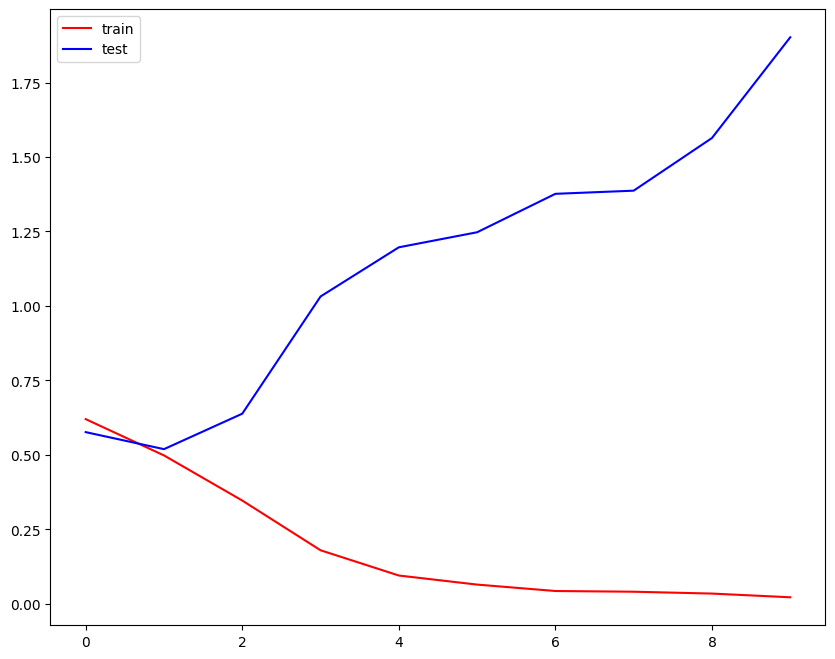

In [24]:
plt.figure(figsize=(10, 8))
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='test')
plt.legend()
plt.show()

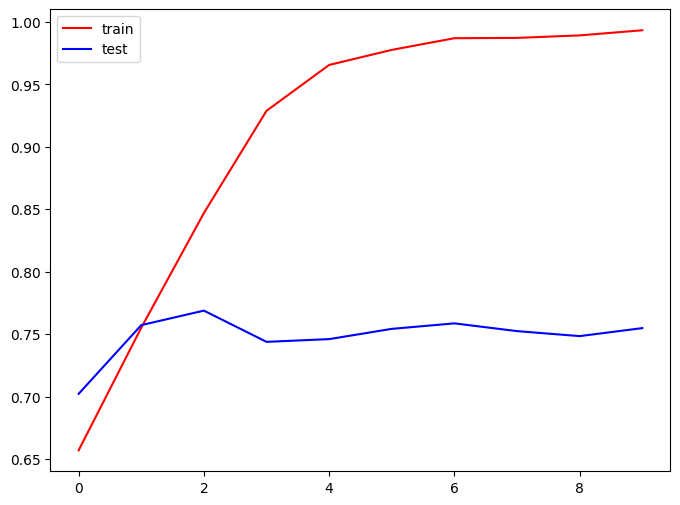

In [23]:
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='test')
plt.legend()
plt.show()

In [25]:
import cv2

In [26]:
dog_image = cv2.imread('cats_dogs_prediction_images/dog.jpg')

In [33]:
dog_image = cv2.resize(dog_image, (256, 256))

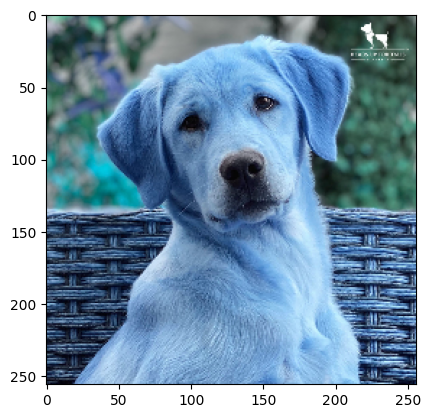

In [34]:
plt.imshow(dog_image)

In [47]:
cat_image = cv2.imread('cats_dogs_prediction_images/cat.jpg')

In [48]:
cat_image = cv2.resize(cat_image, (256,256))

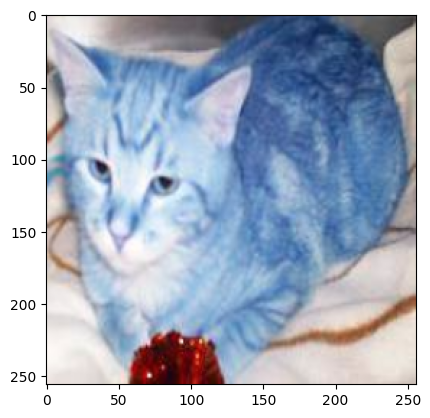

In [49]:
plt.imshow(cat_image)

In [50]:
test_dog = dog_image.reshape((1, 256, 256, 3))
test_cat = cat_image.reshape((1, 256, 256, 3))

In [51]:
model.predict(test_cat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


array([[0.]], dtype=float32)

In [52]:
model.predict(test_dog)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


array([[1.]], dtype=float32)